In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import  spearmanr
import pandas as pd

In [12]:
cyto=pd.read_excel("../Data_preprocessing/Scaled_data_6m.xlsx")

In [14]:
cyto=cyto.set_index('Unnamed: 0')

In [15]:
cytokines=["crp_6mo","il_1β_6mo","il_8_6mo","il_6_6mo","tnf_α_6mo"]

In [16]:
corr_mat=cyto.corr(method="spearman").drop(cytokines,axis=0).loc[:,cytokines]

In [17]:
def calculate_pvalues(df):
    df = df._get_numeric_data()
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose()
    pvalues.index=df.columns
    corr = dfcols.transpose()
    corr.index=df.columns
    for r in df.columns:
        for c in df.columns:
            if c == r:
                pvalues.loc[r,c]=1
            else:
                df_corr = df.loc[:,[r,c]].dropna()
                pvalues.loc[r,c] = spearmanr(df_corr.loc[:,r], df_corr.loc[:,c])[1]
                corr.loc[r,c] = spearmanr(df_corr.loc[:,r], df_corr.loc[:,c])[0]
    return df.corr(method="spearman"),pvalues

In [18]:
corr,p=calculate_pvalues(cyto)

In [19]:
adjusted=[ 'crp_6mo', 'il_1β_6mo',
       'il_8_6mo', 'il_6_6mo', 'tnf_α_6mo']

In [20]:
corr,p=calculate_pvalues(cyto)


mask=p*cyto.shape[0]<0.05

In [21]:
useless=['verificeret_12y', 'verificeret_18y',
       'urti_1y', 'rti_1y', 'fever_1y', 'gi_1y', 'any_1y', 'lrti_3yr',
       'urti_3yr', 'rti_3yr', 'fever_3yr', 'gi_3yr', 'any_3yr',
       'genetic_risk_score_asthma','asthma_0_7yrs']

In [22]:
p_shape=p.drop(cytokines+adjusted+useless,axis=0).loc[:,cytokines]

In [23]:
soft_max=mask.drop(cytokines+adjusted+useless,axis=0).loc[:,cytokines]

In [24]:
corr_shape=corr.drop(cytokines+adjusted+useless,axis=0).loc[:,cytokines]

In [25]:
columns=["CPR","$IL \ 1 \u03B2 $","IL 8","IL 6" ,"$TNF \ \u03B1 $" ]

<>:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/tmp/ipykernel_775603/2711363959.py:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  columns=["CPR","$IL \ 1 \u03B2 $","IL 8","IL 6" ,"$TNF \ \u03B1 $" ]
/tmp/ipykernel_775603/2711363959.py:1: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the futur

In [26]:
index1=["Indoor $PM_{2.5}$","Indoor Formalhyde","Street $NO_2$","Street $PM_{2,5}$","Street $NO_x$" ,"Indoor $NO_x$","Indoor Acetald"," Indoor Actone","Indoor Black Carbon","Urban $NO_x$","Urban $NO_x$","Urban $PM_{2,5}$","Indoor Humidity","Fel d1","Der f1"]

In [27]:
index2=["Der p1","Can f1","Indoor temperature","Cotinine hair","Genetics","Gestational age",'Constrution year','Area',
       'Floor level',"Airport" ,"Forest","Moterway","Road","Farmland"]

In [28]:
corr_shape.index

Index(['constrution_year', 'Area', 'floor_level', 'powerplant', 'road',
       'motorway', 'forest', 'coastline', 'airport', 'farmland', 'industrial',
       'carpet', 'cookerhood', 'passive', 'gastove', 'fireplace', 'scaled_bc',
       'scaled_PM25', 'scaled_nox', 'scaled_no2', 'scaled_formaldehyd',
       'scaled_acetone', 'scaled_acetald', 'no2_str_m6', 'nox_str_m6',
       'pm25_str_m6', 'bmi_6_yrs', 'gestational_age', 'mother's_education_1yr',
       'lrti_1y'],
      dtype='str')

In [29]:
index1=['Constrution year',"Area","Floor level","Powerplant","Road", "Moterway","Forest",'Coastline', 'Airport', 'Farmland', 'Industrial',
       'Carpet', 'Cookerhood', 'Passive', 'Gastove', 'Fireplace', 'Black Carbon',
       'PM$_{2.5}$', 'NO$_x$', '$NO_2$', 'Formaldehyde',
       'Acetone', 'Acetaldehyde', 'Street level NO$_2$','Street level NO$_x$',
       'Street level PM$_{2.5}$', 'BMI 6 years', 'Gestational age',
       'Education of Mother first year' ]

In [30]:
corr_shape=corr_shape.rename(dict(zip(corr_shape.columns,columns)),axis=1)
corr_shape=corr_shape.rename(dict(zip(corr_shape.index,index1)),axis=0)

In [31]:
corr_shape.index


Index(['Constrution year', 'Area', 'Floor level', 'Powerplant', 'Road',
       'Moterway', 'Forest', 'Coastline', 'Airport', 'Farmland', 'Industrial',
       'Carpet', 'Cookerhood', 'Passive', 'Gastove', 'Fireplace',
       'Black Carbon', 'PM$_{2.5}$', 'NO$_x$', '$NO_2$', 'Formaldehyde',
       'Acetone', 'Acetaldehyde', 'Street level NO$_2$', 'Street level NO$_x$',
       'Street level PM$_{2.5}$', 'BMI 6 years', 'Gestational age',
       'Education of Mother first year', 'lrti_1y'],
      dtype='str')

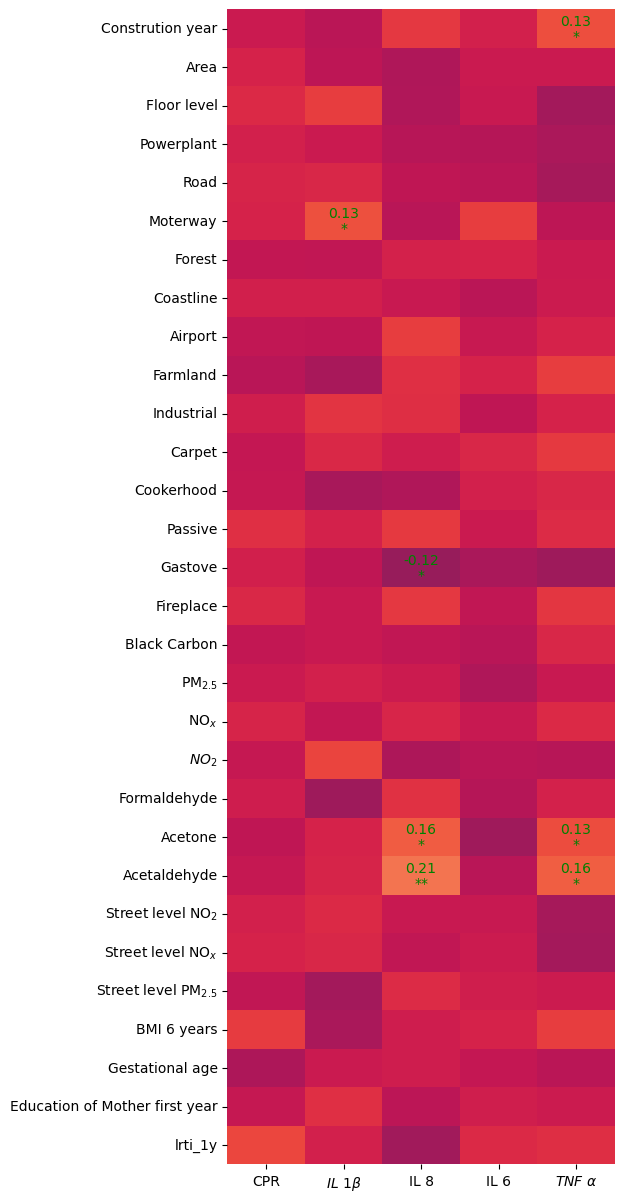

In [34]:
fig,ax=plt.subplots(1,1,figsize=(5,15))
g=sns.heatmap(corr_shape, fmt='g',ax=ax,vmin=-0.5,vmax=0.5,cbar=False)
for i in range(corr_shape.shape[0]):
    for j in range(corr_shape.shape[1]):
        if p_shape.iloc[i, j]<0.05:
            corr = '{:.2f}'.format(corr_shape.iloc[i, j].round(2)),
            pval = p_shape.iloc[i, j].round(1)
            if p_shape.iloc[i, j]*p_shape.shape[0]<0.05:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='green')
                ax.text(j+0.5, i+0.7, "**", ha='center', va='center', fontsize=10, color='green')
            else:
                ax.text(j+0.5, i+0.3, corr[0], ha='center', va='center', fontsize=10, color='green')
                ax.text(j+0.5, i+0.7, "*", ha='center', va='center', fontsize=10, color='green')
            
fig.savefig("../Plots/cytokine_responds_exposures.png",bbox_inches="tight")